In [1]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim


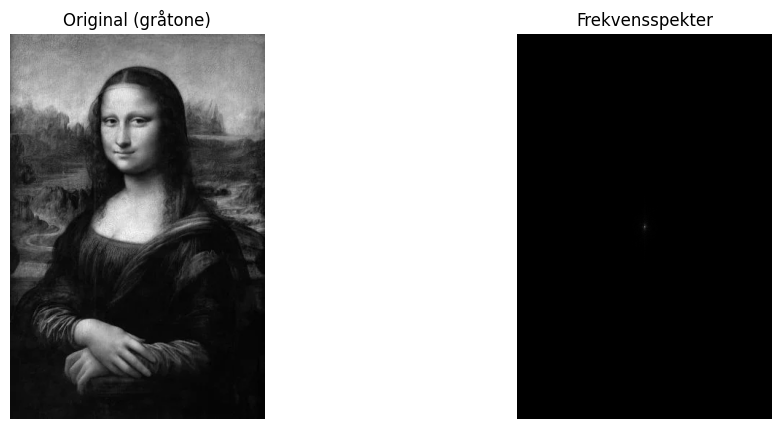

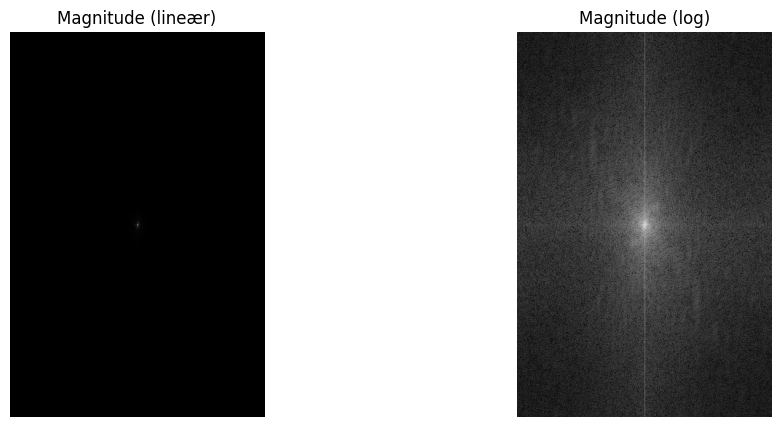

In [35]:
#oppgave 1A)

plt.rcParams["figure.figsize"] = (6, 6)

def imread_grayscale(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0

image_path = "Mona_Lisa_GS2.webp"   
img = imread_grayscale(image_path)


F = np.fft.fft2(img)     
        
Fshift = np.fft.fftshift(F)      
mag_lin = np.abs(Fshift)
mag_log = np.log1p(np.abs(Fshift))   

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original (gråtone)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mag_lin, cmap="gray")
plt.title("Frekvensspekter")
plt.axis("off")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(mag_lin, cmap='gray'); plt.title("Magnitude (lineær)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(mag_log, cmap='gray'); plt.title("Magnitude (log)"); plt.axis('off')
plt.show()


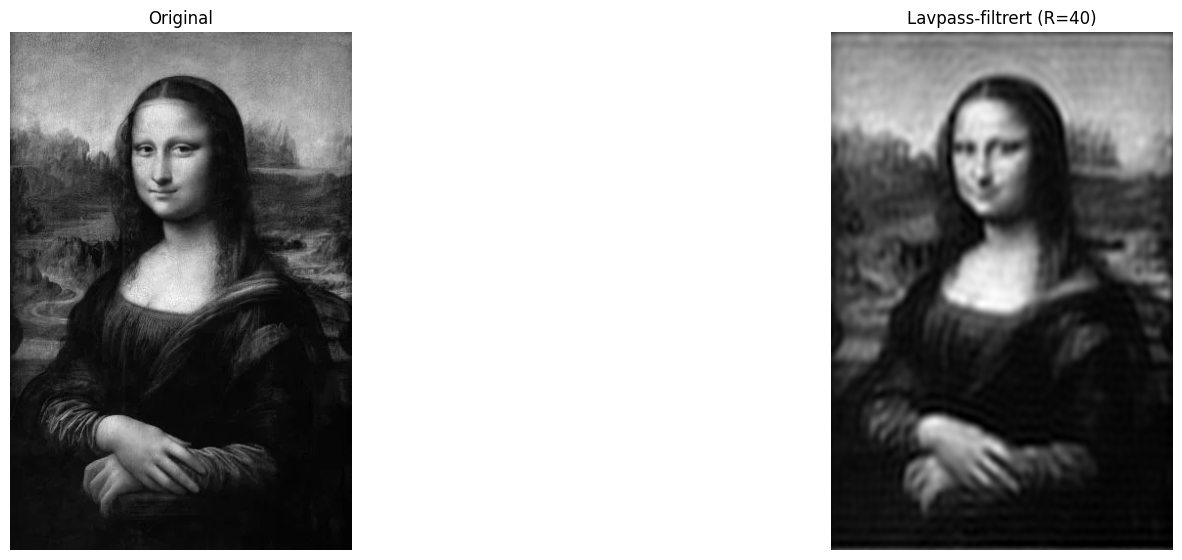

In [ ]:
#oppgave 1B)

import numpy as np
import matplotlib.pyplot as plt

def circular_mask(shape, radius):
    r, c = shape
    cy, cx = r//2, c//2
    Y, X = np.ogrid[:r, :c]
    return (Y - cy)**2 + (X - cx)**2 <= radius**2

R = 40  #mindre R = mer utglatting
mask_lpf = circular_mask(img.shape, R)

F_lpf = Fshift * mask_lpf
img_lpf = np.fft.ifft2(np.fft.ifftshift(F_lpf)).real
img_lpf = np.clip(img_lpf, 0, 1)

plt.figure(figsize=(15,15))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(img_lpf, cmap="gray"); plt.title(f"Lavpass-filtrert (R={R})"); plt.axis("off")
plt.show()


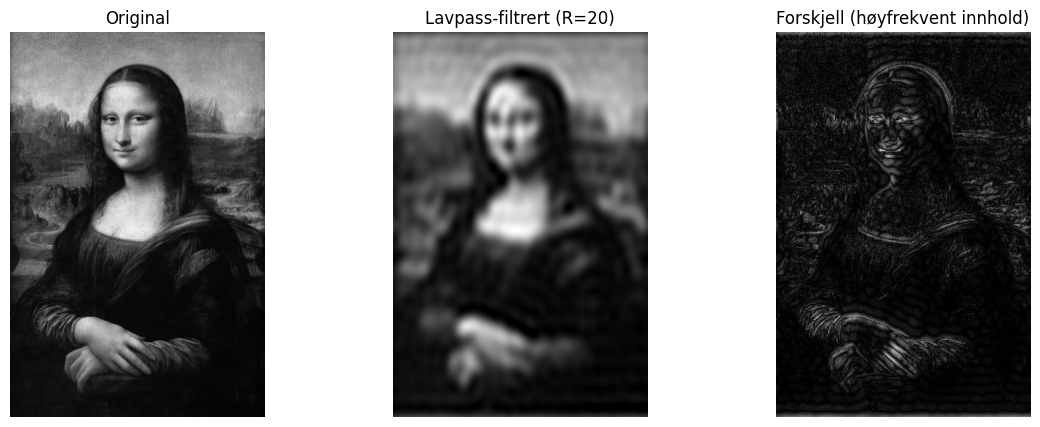

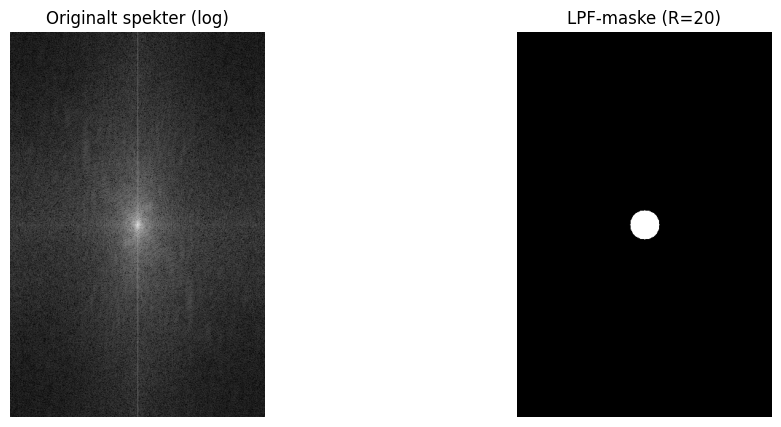

In [ ]:
# Oppgave 1B 

import numpy as np
import matplotlib.pyplot as plt

F = np.fft.fft2(img)
Fshift = np.fft.fftshift(F)

def circular_mask(shape, radius):
    r, c = shape
    cy, cx = r//2, c//2
    Y, X = np.ogrid[:r, :c]
    return (Y - cy)**2 + (X - cx)**2 <= radius**2

R = 20  # mindre R = mer støyfjerning/mer blur, større R = mer detaljer beholdt
mask_lpf = circular_mask(img.shape, R)

F_lpf = Fshift * mask_lpf
img_lpf = np.fft.ifft2(np.fft.ifftshift(F_lpf)).real
img_lpf = np.clip(img_lpf, 0, 1)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(img_lpf, cmap="gray"); plt.title(f"Lavpass-filtrert (R={R})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(np.abs(img - img_lpf)/(np.abs(img - img_lpf).max()+1e-8), cmap="gray"); 
plt.title("Forskjell (høyfrekvent innhold)"); plt.axis("off")
plt.show()


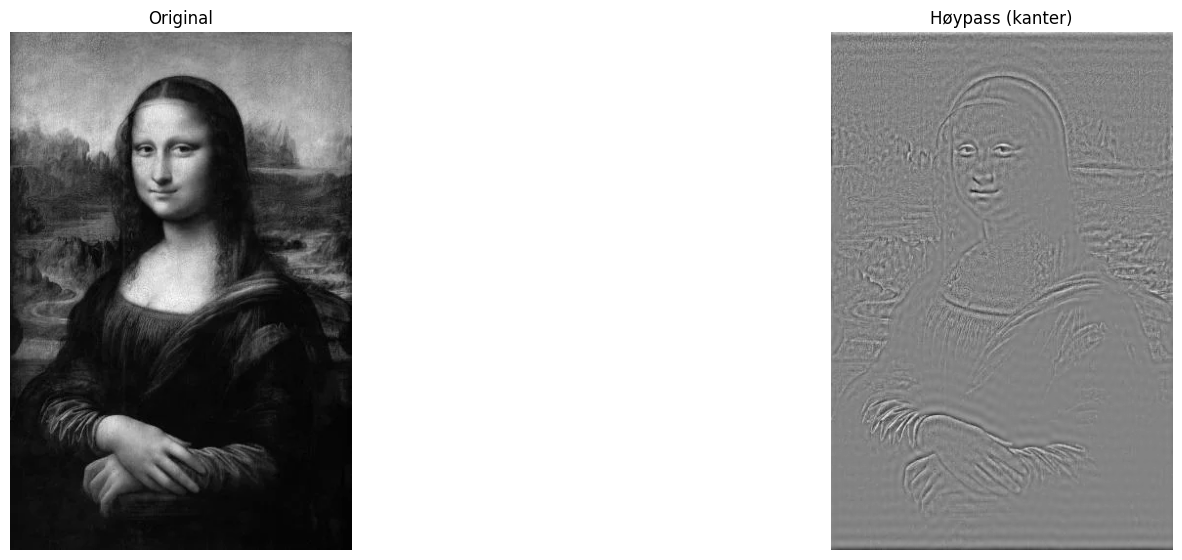

In [47]:
#Oppgave 1C) 


import numpy as np
import matplotlib.pyplot as plt

R = 40

def circular_mask(shape, radius):
    r, c = shape
    cy, cx = r//2, c//2
    Y, X = np.ogrid[:r, :c]
    return (Y - cy)**2 + (X - cx)**2 <= radius**2

mask_hpf = ~circular_mask(img.shape, R)

F_hpf = Fshift * mask_hpf
hp = np.fft.ifft2(np.fft.ifftshift(F_hpf)).real

hp_disp = hp - hp.min()
hp_disp = hp_disp / (hp_disp.max() + 1e-8)

plt.figure(figsize=(15,15))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(hp_disp, cmap="gray"); plt.title("Høypass (kanter)"); plt.axis("off")
plt.show()


In [55]:
import numpy as np

def keep_top_percent(Fs: np.ndarray, percent: float):
    A = np.abs(Fs)
    flat = A.ravel()
    k = max(1, int(np.ceil(flat.size * (percent / 100.0))))
    thresh = np.partition(flat, -k)[-k]
    mask = (A >= thresh)
    Fk = Fs * mask
    rec = np.fft.ifft2(np.fft.ifftshift(Fk)).real
    rec = np.clip(rec, 0, 1).astype(np.float32)

    kept_ratio = mask.sum() / mask.size
    return rec, mask, kept_ratio


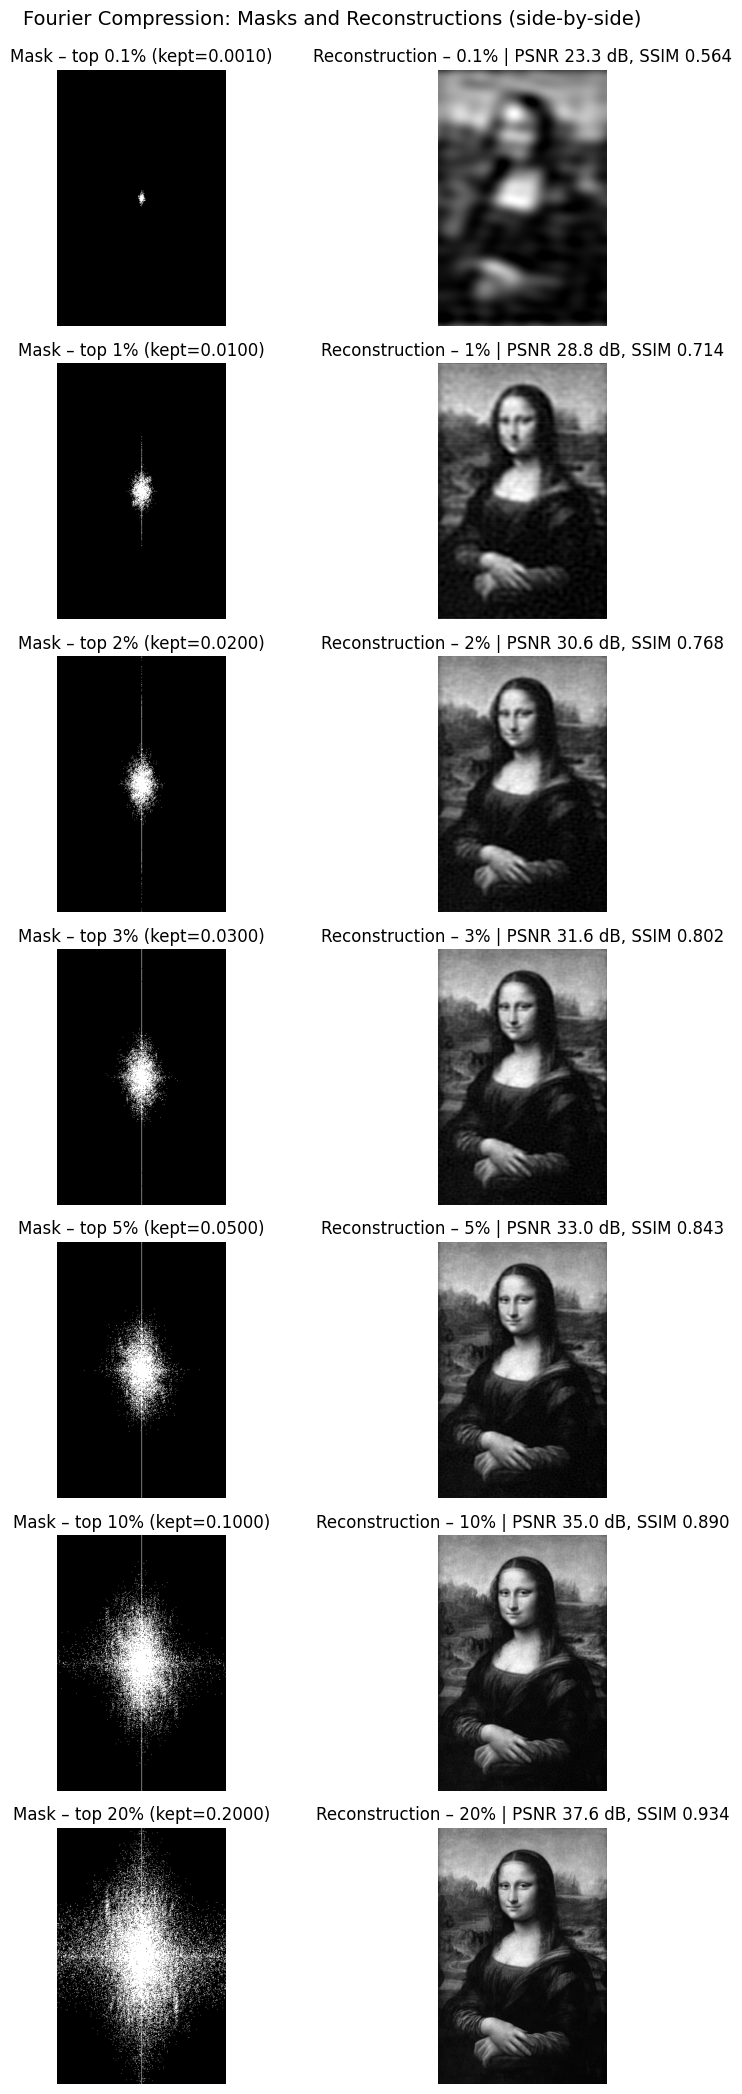

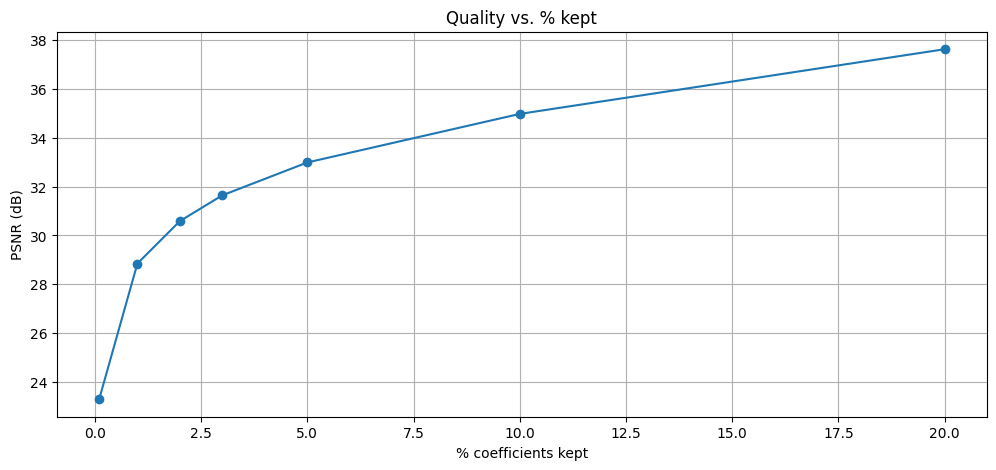

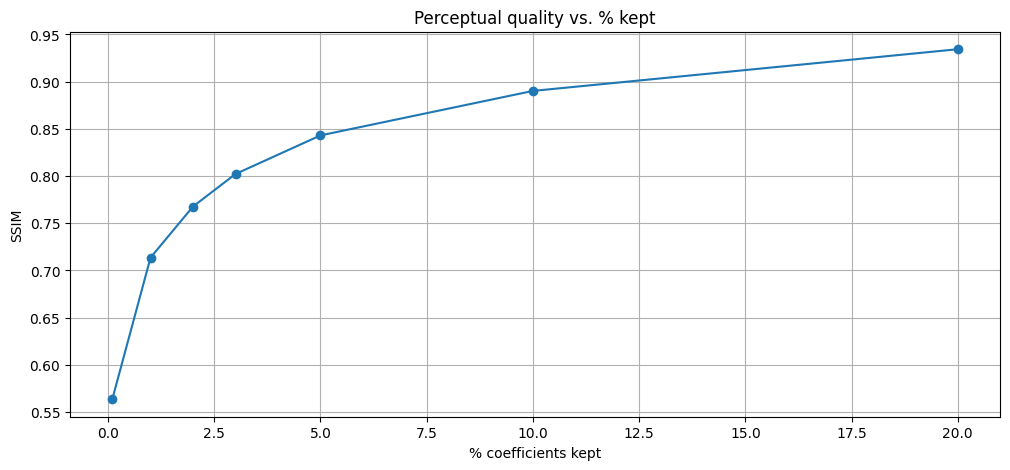

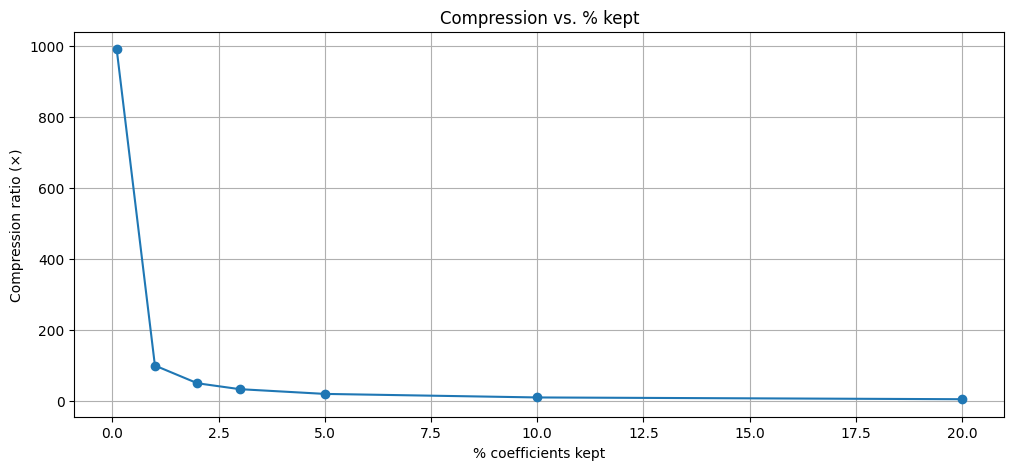

In [56]:


perc_list = [0.1, 1, 2, 3, 5, 10, 20]

rows = []  
for p in perc_list:
    rec, mask, kept = keep_top_percent(Fshift, p)
    P = psnr(img, rec, data_range=1.0)
    S = ssim(img, rec, data_range=1.0)
    rows.append({"p": p, "mask": mask, "rec": rec, "kept": kept, "psnr": P, "ssim": S})

# 1) ÉN stor figur: alle masker og bilder side om side (2 kolonner: [maske | rekonstruksjon])
n = len(rows)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, 3*n))

if n == 1:
    axes = np.array([axes])  # sikre 2D-indeksering hvis bare én rad

for i, r in enumerate(rows):
    # Maske (venstre)
    axm = axes[i, 0]
    axm.imshow(r["mask"], cmap="gray")
    axm.set_title(f"Mask – top {r['p']}% (kept={r['kept']:.4f})")
    axm.axis("off")

    # Rekonstruksjon (høyre)
    axr = axes[i, 1]
    axr.imshow(r["rec"], cmap="gray")
    axr.set_title(f"Reconstruction – {r['p']}% | PSNR {r['psnr']:.1f} dB, SSIM {r['ssim']:.3f}")
    axr.axis("off")

plt.suptitle("Fourier Compression: Masks and Reconstructions (side-by-side)", y=0.995, fontsize=14)
plt.tight_layout()
plt.show()

# 2) Ekstra plott: PSNR, SSIM, Kompresjon
pcts  = [r["p"] for r in rows]
keptR = [r["kept"] for r in rows]
psnrs = [r["psnr"] for r in rows]
ssims = [r["ssim"] for r in rows]
compr = [1.0/k for k in keptR]

plt.figure()
plt.plot(pcts, psnrs, marker="o")
plt.xlabel("% coefficients kept")
plt.ylabel("PSNR (dB)")
plt.title("Quality vs. % kept")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(pcts, ssims, marker="o")
plt.xlabel("% coefficients kept")
plt.ylabel("SSIM")
plt.title("Perceptual quality vs. % kept")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(pcts, compr, marker="o")
plt.xlabel("% coefficients kept")
plt.ylabel("Compression ratio (×)")
plt.title("Compression vs. % kept")
plt.grid(True)
plt.show()

